In [24]:
import pyana
import numpy as np 
import matplotlib.pyplot as plt 

In [25]:
obs = pyana.fzread("cube_to_invert.f0")["data"]
obs.shape

(11, 11, 4, 967)

In [26]:
fit = pyana.fzread("inverted_spectra.f0")["data"]
fit.shape

(11, 11, 4, 967)

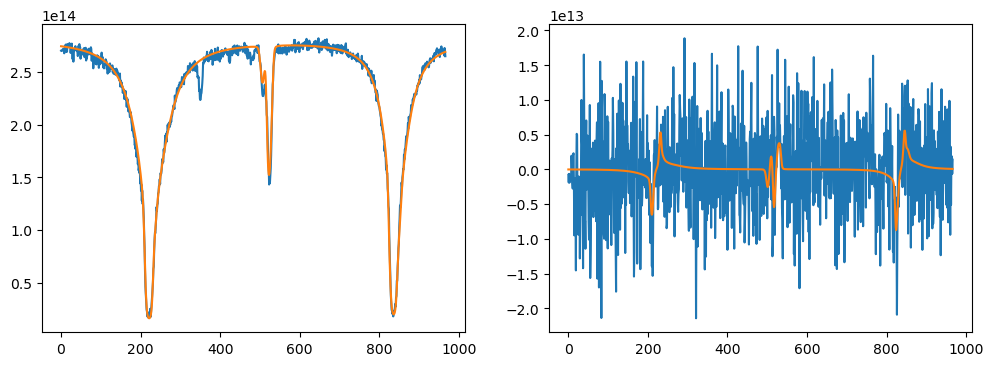

In [41]:
i = 4
j = 4

plt.figure(figsize=[12.0,4.0])
plt.subplot(121)
plt.plot(obs[i,j,0])
plt.plot(fit[i,j,0])
plt.subplot(122)
plt.plot(obs[i,j,3])
plt.plot(fit[i,j,3])

In [42]:
meano = np.mean(obs,axis=(0,1))
meanf = np.mean(fit,axis=(0,1))

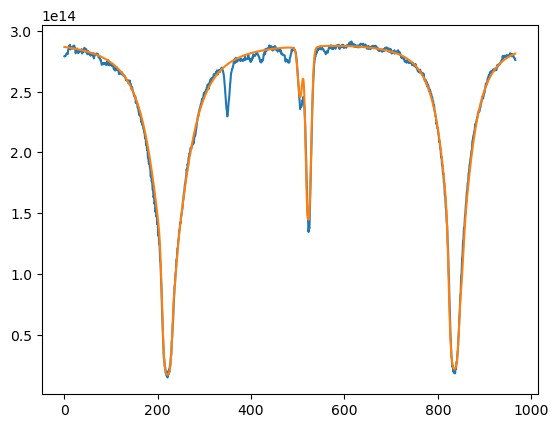

In [43]:
plt.plot(meano[0])
plt.plot(meanf[0])

In [28]:
mask = np.loadtxt("/home/milic/codes/snapi/cfg/sodium_lines_mask.dat",skiprows=2,unpack=True)


In [29]:
res = (fit-obs) * mask[None,None,None,:]
chisq = np.sum(res**2.0,axis=(2,3)) / len(mask) / 4.0 / (3.275E14 * 1E-2) ** 2.0

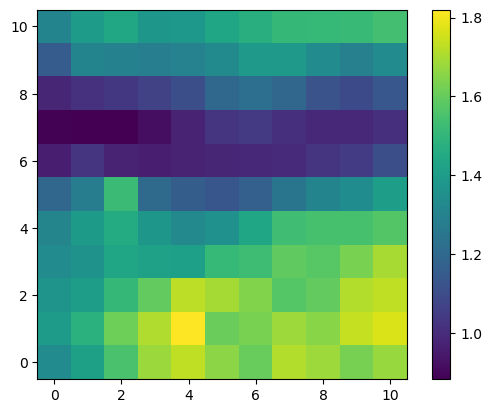

In [30]:
plt.imshow(chisq.T, origin='lower')
plt.colorbar()

In [31]:
atmos = pyana.fzread("inverted_atmos.f0")["data"]

In [32]:
atmos.shape

(12, 11, 11, 31)

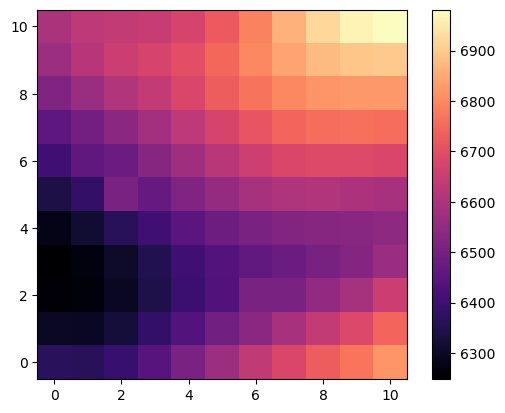

In [39]:
plt.imshow(atmos[2,:,:,-5].T, cmap='magma', origin='lower')
plt.colorbar()

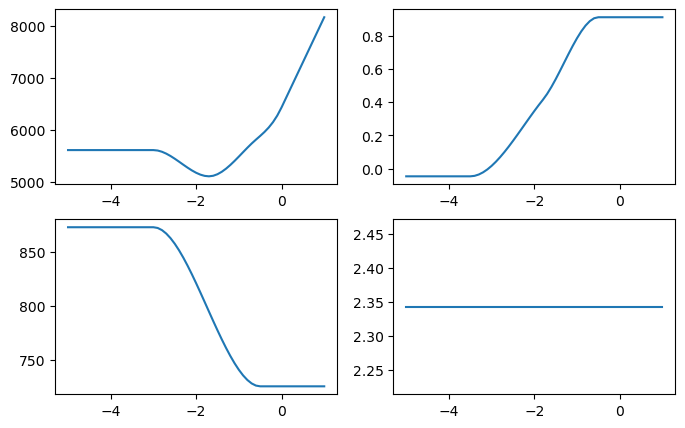

In [8]:
plt.figure(figsize=[8,5])
plt.subplot(221)
plt.plot(atmos[0,0,0],atmos[2,0,0])
plt.subplot(222)
plt.plot(atmos[0,0,0],atmos[9,0,0]/-1E5)
plt.subplot(223)
plt.plot(atmos[0,0,0],atmos[7,0,0])
plt.subplot(224)
plt.plot(atmos[0,0,0],atmos[10,0,0])